In [12]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/processed/clean_nav.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["amfi_code", "date"])
df["daily_return"] = (
    df.groupby("amfi_code")["nav"]
      .pct_change()
)
annualized_returns = (
    df.groupby("amfi_code")["daily_return"]
      .transform(
          lambda x: ((1 + x.dropna()).prod() ** (252 / len(x.dropna())) - 1)
          if len(x.dropna()) > 0 else np.nan
      )
)
df["annualized_return"] = annualized_returns
df.to_csv("../data/processed/returns_computed.csv", index=False)
print("returns_computed.csv generated successfully.")

returns_computed.csv generated successfully.


In [11]:
import pandas as pd
import numpy as np
nav_df = pd.read_csv("../data/processed/clean_nav.csv")
fund_master_df = pd.read_csv("../data/processed/clean_fund_master.csv")
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])
def get_start_nav(group, end_date, years):
    start_date = end_date - pd.DateOffset(years=years)
    temp = group[group['date'] <= start_date]
    if temp.empty:
        return np.nan
    return temp.iloc[-1]['nav']
# CAGR computation
results = []
for amfi_code, group in nav_df.groupby('amfi_code'):
    group = group.sort_values('date')
    end_row = group.iloc[-1]
    nav_end = end_row['nav']
    end_date = end_row['date']
    row = {
        'amfi_code': amfi_code,
        'nav_end': nav_end,
        'end_date': end_date
    }
    for period in [1, 3, 5]:
        start_nav = get_start_nav(group, end_date, period)
        if pd.notna(start_nav) and start_nav > 0:
            cagr = (nav_end / start_nav) ** (1 / period) - 1
        else:
            cagr = np.nan
        row[f'{period}yr_cagr'] = cagr
    results.append(row)
cagr_df = pd.DataFrame(results)
cagr_df = cagr_df.merge(fund_master_df, on='amfi_code', how='left')
cagr_df = cagr_df[
    [
        'amfi_code',
        'scheme_name',
        '1yr_cagr',
        '3yr_cagr',
        '5yr_cagr'
    ]
]
cagr_df.to_csv("../data/processed/cagr_report.csv", index=False)
print("CAGR report generated successfully!")

CAGR report generated successfully!


In [14]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/processed/clean_nav.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["amfi_code", "date"])
df["daily_return"] = df.groupby("amfi_code")["nav"].pct_change()
rf_annual = 0.065
rf_daily = rf_annual / 252
# Sharpe calculation per fund
def compute_sharpe(x):
    excess_return = x["daily_return"] - rf_daily
    std = x["daily_return"].std()
    if std == 0 or np.isnan(std):
        return np.nan
    sharpe = (excess_return.mean() / std) * np.sqrt(252)
    return sharpe
sharpe_df = df.groupby("amfi_code").apply(compute_sharpe).reset_index()
sharpe_df.columns = ["amfi_code", "sharpe_ratio"]
sharpe_df.to_csv("../data/processed/sharpe_values.csv", index=False)
print("Sharp values generated successfully!")

Sharp values generated successfully!


In [16]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/processed/clean_nav.csv")  
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['amfi_code', 'date'])
df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()
rf_annual = 0.065
rf_daily = (1 + rf_annual) ** (1/252) - 1
df['excess_return'] = df['daily_return'] - rf_daily
df['downside'] = np.where(df['excess_return'] < 0, df['excess_return'], 0)
result = df.groupby('amfi_code').agg(
    mean_excess_return=('excess_return', 'mean'),
    downside_std=('downside', lambda x: np.sqrt((x**2).mean()))
).reset_index()
result['sortino_ratio'] = (
    (result['mean_excess_return'] * 252) /
    (result['downside_std'] * np.sqrt(252))
)
result.to_csv("../data/processed/sortino_values.csv", index=False)
print("Sortino values generated successfully!")

Sortino values generated successfully!


In [20]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
fund_df = pd.read_csv("../data/processed/clean_nav.csv")  
index_df = pd.read_csv("../data/processed/clean_benchmark_indices.csv")
index_df['date'] = pd.to_datetime(index_df['date'])
fund_df['date'] = pd.to_datetime(fund_df['date'])
index_df = index_df[index_df['index_name'] == "NIFTY100"].copy()
index_df = index_df.sort_values('date')
fund_df = fund_df.sort_values(['amfi_code', 'date'])

# -----------------------------
# Compute returns
# -----------------------------
index_df['index_return'] = index_df['close_value'].pct_change()

fund_df['fund_return'] = fund_df.groupby('amfi_code')['nav'].pct_change()
merged = pd.merge(
    fund_df,
    index_df[['date', 'index_return']],
    on='date',
    how='inner'
)
merged = merged.dropna(subset=['fund_return', 'index_return'])
rf = 0.0
results = []
for fund, df in merged.groupby('amfi_code'):

    if len(df) < 30:   # avoid noisy regression
        continue
    X = df['index_return'].values
    Y = df['fund_return'].values
    slope, intercept, r, p, std_err = linregress(X, Y)
    beta = slope
    alpha_daily = intercept
    alpha_annual = alpha_daily * 252
    results.append({
        "amfi_code": fund,
        "alpha_daily": alpha_daily,
        "alpha_annual": alpha_annual,
        "beta": beta,
        "r_squared": r**2
    })
alpha_beta_df = pd.DataFrame(results)
alpha_beta_df.to_csv("../data/processed/alpha_beta.csv", index=False)
print("Alpha Beta generated successfully!")

Alpha Beta generated successfully!


In [21]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/processed/clean_nav.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['amfi_code', 'date'])
df['running_max'] = df.groupby('amfi_code')['nav'].cummax()
df['drawdown'] = df['nav'] / df['running_max'] - 1
trough_indices = df.groupby('amfi_code')['drawdown'].idxmin()
worst_periods = df.loc[trough_indices].copy()
peak_dates = []
for idx in trough_indices:
    row = df.loc[idx]
    history = df[(df['amfi_code'] == row['amfi_code']) & (df['date'] <= row['date'])]
    peak_date = history.loc[history['nav'].idxmax(), 'date']
    peak_dates.append(peak_date)
worst_periods['peak_date'] = peak_dates
max_dd = worst_periods[['amfi_code', 'peak_date', 'date', 'drawdown']].rename(
    columns={'date': 'trough_date', 'drawdown': 'max_drawdown'}
)
max_dd.to_csv("../data/processed/max_drawdown.csv", index=False)
print("Maximum Drawdown generated successfully!")

Maximum Drawdown generated successfully!


In [28]:
import pandas as pd
import numpy as np
returns = pd.read_csv("../data/processed/clean_performance.csv")[["amfi_code", "return_3yr_pct"]]
sharpe = pd.read_csv("../data/processed/sharpe_values.csv")[["amfi_code", "sharpe_ratio"]]
alpha = pd.read_csv("../data/processed/alpha_beta.csv")[["amfi_code", "alpha_annual"]]
mdd = pd.read_csv("../data/processed/max_drawdown.csv")[["amfi_code", "max_drawdown"]]
master = pd.read_csv("../data/processed/clean_fund_master.csv")[["amfi_code", "scheme_name", "fund_house", "expense_ratio_pct"]]
df = returns.merge(sharpe, on="amfi_code", how="inner") \
            .merge(alpha, on="amfi_code", how="inner") \
            .merge(mdd, on="amfi_code", how="inner") \
            .merge(master, on="amfi_code", how="inner")
n = len(df)

df["return_rank"] = df["return_3yr_pct"].rank(ascending=False)
df["sharpe_rank"] = df["sharpe_ratio"].rank(ascending=False)
df["alpha_rank"] = df["alpha_annual"].rank(ascending=False)

df["expense_rank"] = df["expense_ratio_pct"].rank(ascending=True)
df["mdd_rank"] = (-df["max_drawdown"]).rank(ascending=False)
n = len(df)

df["score"] = (
    0.30 * (n - df["return_rank"] + 1) / n +
    0.25 * (n - df["sharpe_rank"] + 1) / n +
    0.20 * (n - df["alpha_rank"] + 1) / n +
    0.15 * (n - df["expense_rank"] + 1) / n +
    0.10 * (n - df["mdd_rank"] + 1) / n
) * 100
output = df[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "return_3yr_pct",
    "sharpe_ratio",
    "alpha_annual",
    "expense_ratio_pct",
    "max_drawdown",
    "score"
]]

output = output.sort_values("score", ascending=False)

output.to_csv("../data/processed/fund_scorecard.csv", index=False)

print("fund scorecard generated successfully")

fund scorecard generated successfully


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
fund_df = pd.read_csv("../data/processed/clean_nav.csv")  
index_df = pd.read_csv("../data/processed/clean_performance.csv")  
fund_df["date"] = pd.to_datetime(fund_df["date"])
index_df["date"] = pd.to_datetime(index_df["date"])
fund_df = fund_df.sort_values(["amfi_code", "date"])
index_df = index_df.sort_values(["index_name", "date"])
fund_df["fund_return"] = fund_df.groupby("amfi_code")["nav"].pct_change()
index_df["index_return"] = index_df.groupby("index_name")["close_value"].pct_change()
bench_ret = index_df.pivot(index="date", columns="index_name", values="index_return")
bench_ret = bench_ret.rename(columns={
    "Nifty 50": "NIFTY50",
    "Nifty 100": "NIFTY100"
})
fund_cagr = (
    fund_df.groupby("amfi_code")
    .apply(lambda x: (1 + x["fund_return"].dropna()).prod() ** (252 / len(x.dropna())) - 1)
)

top5_funds = fund_cagr.sort_values(ascending=False).head(5).index.tolist()

# ---------------------------
# Filter top 5 funds
# ---------------------------
fund_top = fund_df[fund_df["amfi_code"].isin(top5_funds)].copy()

merged = fund_top.merge(bench_ret, left_on="date", right_index=True, how="inner")
def tracking_error(fund_ret, bench_ret):
    active = fund_ret - bench_ret
    return np.std(active.dropna()) * np.sqrt(252)
plt.figure(figsize=(14, 8))

results = []

for i, fund in enumerate(top5_funds):
    df_f = merged[merged["amfi_code"] == fund].copy()

    # cumulative returns
    df_f["fund_cum"] = (1 + df_f["fund_return"]).cumprod()
    df_f["nifty50_cum"] = (1 + df_f["nifty50"]).cumprod()
    df_f["nifty100_cum"] = (1 + df_f["nifty100"]).cumprod()

    # tracking error vs Nifty 50
    te = tracking_error(df_f["fund_return"], df_f["nifty50"])
    results.append((fund, te))

    # plot
    plt.plot(df_f["date"], df_f["fund_cum"], label=f"Fund {fund}")
    
plt.plot(df_f["date"], df_f["nifty50_cum"], "--", label="Nifty 50")
plt.plot(df_f["date"], df_f["nifty100_cum"], "--", label="Nifty 100")

# ---------------------------
# Final chart styling
# ---------------------------
plt.title("Top 5 Funds vs Nifty 50 & Nifty 100 (3Y Performance)")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("benchmark_chart.png", dpi=300)
plt.show()

# ---------------------------
# Tracking error output
# ---------------------------
te_df = pd.DataFrame(results, columns=["amfi_code", "tracking_error_vs_nifty50"])
te_df.to_csv("tracking_error.csv", index=False)

print(te_df)

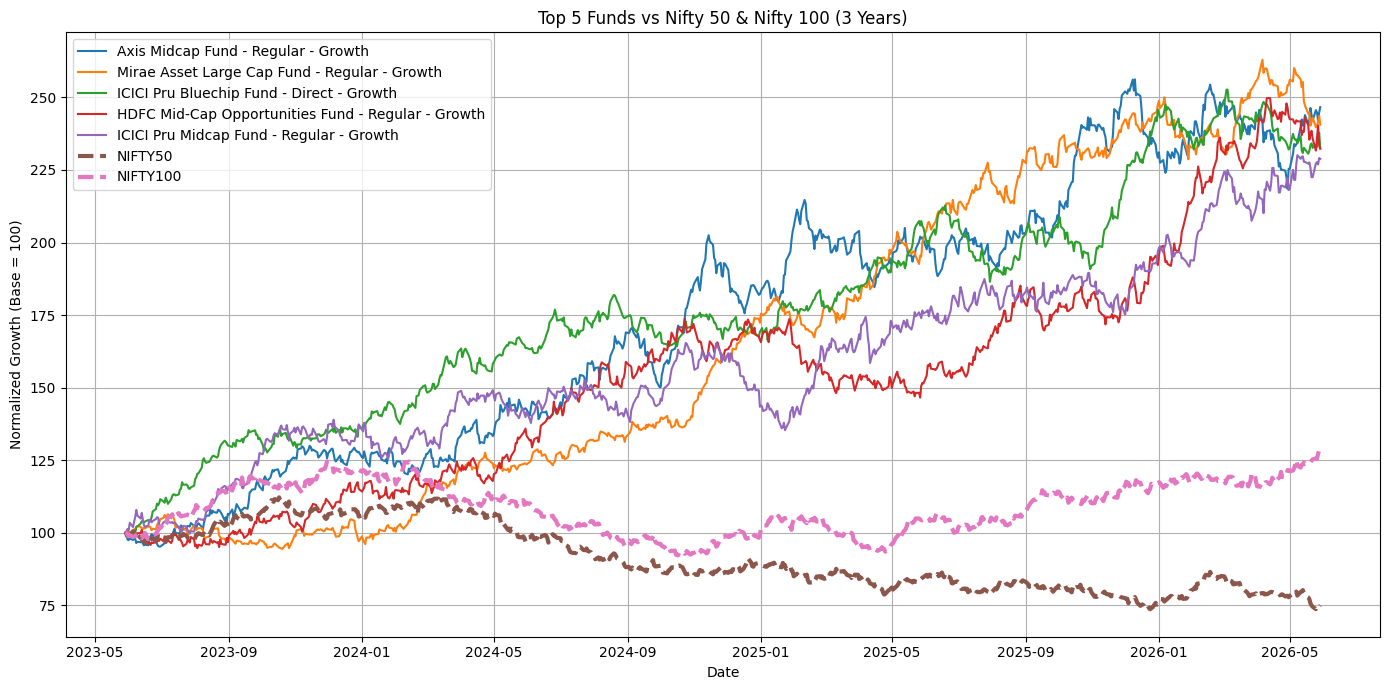

Axis Midcap Fund - Regular - Growth: 0.2388
Mirae Asset Large Cap Fund - Regular - Growth: 0.1919
ICICI Pru Bluechip Fund - Direct - Growth: 0.1882
HDFC Mid-Cap Opportunities Fund - Regular - Growth: 0.2282
ICICI Pru Midcap Fund - Regular - Growth: 0.2284


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
funds = pd.read_csv("../data/processed/cagr_report.csv")  
nav = pd.read_csv("../data/processed/clean_nav.csv")       
index_df = pd.read_csv("../data/processed/clean_benchmark_indices.csv")     
nav["date"] = pd.to_datetime(nav["date"])
index_df["date"] = pd.to_datetime(index_df["date"])
top5 = funds.nlargest(5, "3yr_cagr")
top5_codes = top5["amfi_code"].tolist()
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)
nav = nav[(nav["date"] >= start_date) & (nav["date"] <= end_date)]
index_df = index_df[(index_df["date"] >= start_date) & (index_df["date"] <= end_date)]
plt.figure(figsize=(14, 7))
for code in top5_codes:
    fund = nav[nav["amfi_code"] == code].sort_values("date")
    if len(fund) > 0:
        normalized = fund["nav"] / fund["nav"].iloc[0] * 100
        scheme_name = top5.loc[
            top5["amfi_code"] == code,
            "scheme_name"
        ].iloc[0]
        plt.plot(
            fund["date"],
            normalized,
            label=scheme_name
        )

for benchmark in ["NIFTY50", "NIFTY100"]:
    idx = index_df[index_df["index_name"] == benchmark].sort_values("date")
    if len(idx) > 0:
        normalized = idx["close_value"] / idx["close_value"].iloc[0] * 100
        plt.plot(
            idx["date"],
            normalized,
            linewidth=3,
            linestyle="--",
            label=benchmark
        )

plt.title("Top 5 Funds vs Nifty 50 & Nifty 100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

nifty50 = index_df[index_df["index_name"] == "NIFTY50"].sort_values("date").copy()
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

for code in top5_codes:

    fund = nav[nav["amfi_code"] == code].sort_values("date").copy()
    fund["fund_return"] = fund["nav"].pct_change()

    merged = pd.merge(
        fund[["date", "fund_return"]],
        nifty50[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (merged["fund_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    scheme_name = top5.loc[
        top5["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    print(f"{scheme_name}: {tracking_error:.4f}")